In [3]:
import os
import glob
import zipfile
import shutil
import random
import warnings

import rasterio
from rasterio.enums import Resampling

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

SAFE_PATH = "/content/drive/MyDrive/CS2441/SENTINEL 2 (Image)"
OUTPUT_DIR = "/content/drive/MyDrive/CS2441/full_pipeline_output"
PATCH_DIR = "/content/patches"

os.makedirs(PATCH_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("CS2441 exists:", os.path.exists("/content/drive/MyDrive/CS2441"))
print("SAFE exists:", os.path.exists(SAFE_PATH))
print("Output exists:", os.path.exists(OUTPUT_DIR))

print("SAFE path:", SAFE_PATH)
print("Patch path:", PATCH_DIR)
print("Output path:", OUTPUT_DIR)

Mounted at /content/drive
CS2441 exists: True
SAFE exists: True
Output exists: True
SAFE path: /content/drive/MyDrive/CS2441/SENTINEL 2 (Image)
Patch path: /content/patches
Output path: /content/drive/MyDrive/CS2441/full_pipeline_output


In [5]:
def find_band_file(base_path, band_name, resolution):
    pattern = os.path.join(base_path, "**", f"*_{band_name}_{resolution}.jp2")
    files = glob.glob(pattern, recursive=True)
    if len(files) == 0:
        raise FileNotFoundError(f"{band_name}_{resolution} not found")
    return files[0]

b02_path = find_band_file(SAFE_PATH, "B02", "10m")
b03_path = find_band_file(SAFE_PATH, "B03", "10m")
b04_path = find_band_file(SAFE_PATH, "B04", "10m")
b08_path = find_band_file(SAFE_PATH, "B08", "10m")

try:
    scl_path = find_band_file(SAFE_PATH, "SCL", "20m")
    scl_available = True
except FileNotFoundError:
    scl_path = None
    scl_available = False

print("Blue:", b02_path)
print("Green:", b03_path)
print("Red:", b04_path)
print("NIR:", b08_path)
print("SCL available:", scl_available)

Blue: /content/drive/MyDrive/CS2441/SENTINEL 2 (Image)/GRANULE/L2A_T44QLJ_A008426_20260417T051527/IMG_DATA/R10m/T44QLJ_20260417T050651_B02_10m.jp2
Green: /content/drive/MyDrive/CS2441/SENTINEL 2 (Image)/GRANULE/L2A_T44QLJ_A008426_20260417T051527/IMG_DATA/R10m/T44QLJ_20260417T050651_B03_10m.jp2
Red: /content/drive/MyDrive/CS2441/SENTINEL 2 (Image)/GRANULE/L2A_T44QLJ_A008426_20260417T051527/IMG_DATA/R10m/T44QLJ_20260417T050651_B04_10m.jp2
NIR: /content/drive/MyDrive/CS2441/SENTINEL 2 (Image)/GRANULE/L2A_T44QLJ_A008426_20260417T051527/IMG_DATA/R10m/T44QLJ_20260417T050651_B08_10m.jp2
SCL available: True


In [6]:
with rasterio.open(b02_path) as src:
    blue = src.read(1).astype(np.float32)
    height, width = src.height, src.width
    profile = src.profile

with rasterio.open(b03_path) as src:
    green = src.read(1).astype(np.float32)

with rasterio.open(b04_path) as src:
    red = src.read(1).astype(np.float32)

with rasterio.open(b08_path) as src:
    nir = src.read(1).astype(np.float32)

stacked = np.stack([blue, green, red, nir], axis=0)

print("Stacked shape:", stacked.shape)
print("Band order: Blue, Green, Red, NIR")

Stacked shape: (4, 10980, 10980)
Band order: Blue, Green, Red, NIR


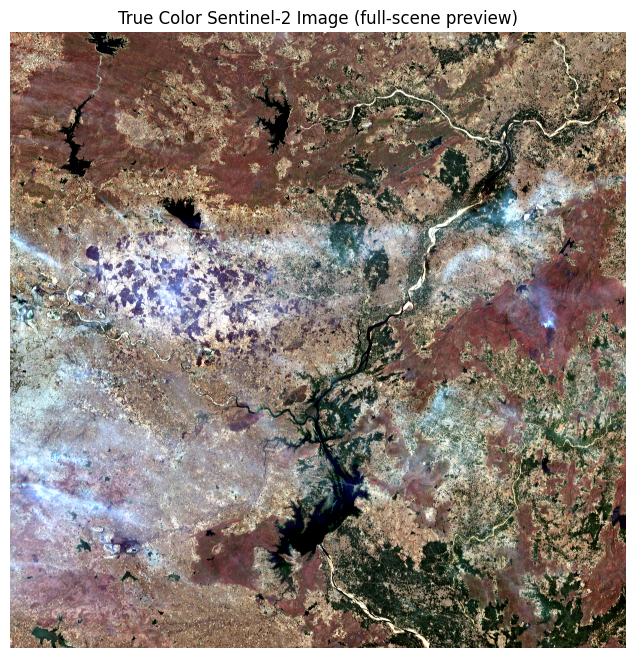

In [7]:
def normalize_percentile(band, low=2, high=98):
    p_low = np.percentile(band, low)
    p_high = np.percentile(band, high)

    if p_high == p_low:
        return np.zeros_like(band, dtype=np.float32)

    clipped = np.clip(band, p_low, p_high)
    return (clipped - p_low) / (p_high - p_low)

preview_true_color = np.dstack((
    normalize_percentile(red),
    normalize_percentile(green),
    normalize_percentile(blue)
))

plt.figure(figsize=(8, 8))
plt.imshow(preview_true_color)
plt.title("True Color Sentinel-2 Image (full-scene preview)")
plt.axis("off")
plt.show()

Cropped RGB shape: (2048, 2048, 3)


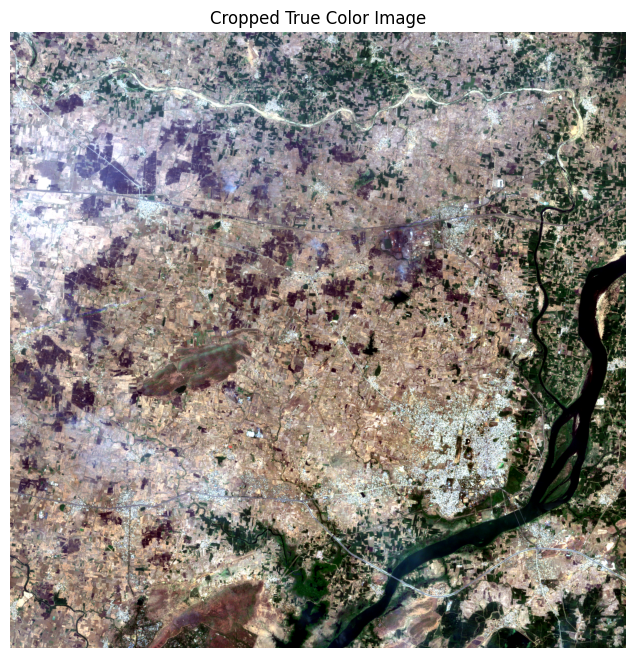

In [8]:
crop_size = 2048

center_y = red.shape[0] // 2
center_x = red.shape[1] // 2

y1 = center_y - crop_size // 2
y2 = center_y + crop_size // 2
x1 = center_x - crop_size // 2
x2 = center_x + crop_size // 2

red = red[y1:y2, x1:x2]
green = green[y1:y2, x1:x2]
blue = blue[y1:y2, x1:x2]
nir = nir[y1:y2, x1:x2]

true_color = np.dstack((
    normalize_percentile(red),
    normalize_percentile(green),
    normalize_percentile(blue)
))
true_color_uint8 = (true_color * 255).astype(np.uint8)

height, width = true_color_uint8.shape[:2]

print("Cropped RGB shape:", true_color_uint8.shape)

plt.figure(figsize=(8, 8))
plt.imshow(true_color_uint8)
plt.title("Cropped True Color Image")
plt.axis("off")
plt.show()

Image.fromarray(true_color_uint8).save(os.path.join(OUTPUT_DIR, "true_color.png"))

In [9]:
cloud_mask = np.zeros((height, width), dtype=bool)

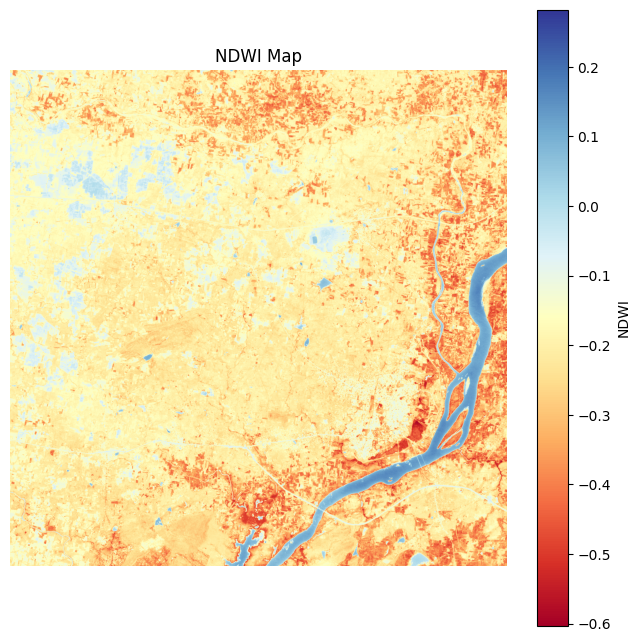

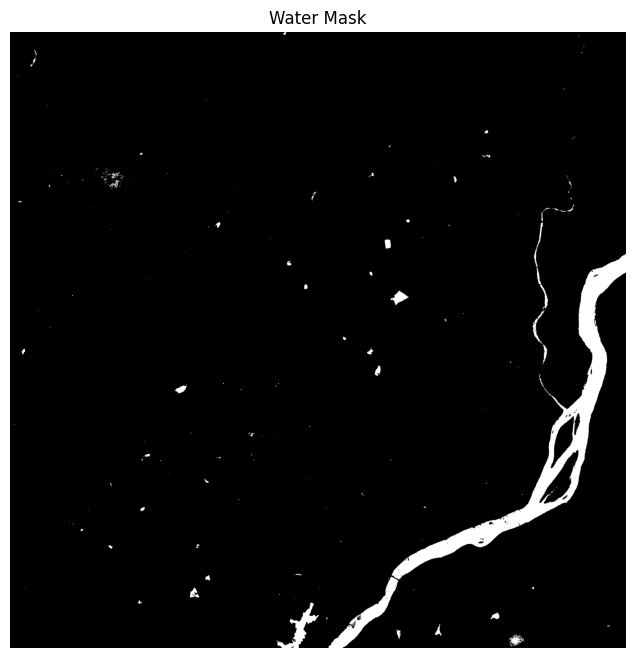

Water pixels: 112163
Non-water pixels: 4082141


In [10]:
ndwi = (green - nir) / (green + nir + 1e-10)

plt.figure(figsize=(8, 8))
plt.imshow(ndwi, cmap="RdYlBu")
plt.colorbar(label="NDWI")
plt.title("NDWI Map")
plt.axis("off")
plt.show()

water_mask = ndwi > 0
water_mask[cloud_mask] = False

water_mask_uint8 = (water_mask * 255).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(water_mask_uint8, cmap="gray")
plt.title("Water Mask")
plt.axis("off")
plt.show()

print("Water pixels:", np.sum(water_mask))
print("Non-water pixels:", water_mask.size - np.sum(water_mask))

In [11]:
patch_size = int(input("Enter patch size, example 128: "))
overlap = int(input("Enter overlap, example 0 or 32: "))

if overlap >= patch_size:
    raise ValueError("Overlap must be smaller than patch size.")

stride = patch_size - overlap

print("Patch size:", patch_size)
print("Overlap:", overlap)
print("Stride:", stride)

Enter patch size, example 128: 64
Enter overlap, example 0 or 32: 32
Patch size: 64
Overlap: 32
Stride: 32


In [12]:
PATCH_DIR = "/content/patches"

if os.path.exists(PATCH_DIR):
    shutil.rmtree(PATCH_DIR)

water_rgb_dir = os.path.join(PATCH_DIR, "water", "rgb")
water_mask_dir = os.path.join(PATCH_DIR, "water", "mask")
nowater_rgb_dir = os.path.join(PATCH_DIR, "no_water", "rgb")
nowater_mask_dir = os.path.join(PATCH_DIR, "no_water", "mask")

for folder in [water_rgb_dir, water_mask_dir, nowater_rgb_dir, nowater_mask_dir]:
    os.makedirs(folder, exist_ok=True)

water_count = 0
nowater_count = 0
skipped_count = 0

water_threshold = 0.10
nowater_threshold = 0.01

rows, cols = water_mask.shape

for y in range(0, rows - patch_size + 1, stride):
    for x in range(0, cols - patch_size + 1, stride):

        rgb_patch = true_color_uint8[y:y+patch_size, x:x+patch_size]
        mask_patch = water_mask_uint8[y:y+patch_size, x:x+patch_size]

        water_ratio = np.sum(mask_patch > 0) / (patch_size * patch_size)

        if water_ratio >= water_threshold:
            Image.fromarray(rgb_patch).save(
                os.path.join(water_rgb_dir, f"water_rgb_{water_count}_ratio_{water_ratio:.3f}.png")
            )
            Image.fromarray(mask_patch).save(
                os.path.join(water_mask_dir, f"water_mask_{water_count}_ratio_{water_ratio:.3f}.png")
            )
            water_count += 1

        elif water_ratio <= nowater_threshold:
            Image.fromarray(rgb_patch).save(
                os.path.join(nowater_rgb_dir, f"nowater_rgb_{nowater_count}_ratio_{water_ratio:.3f}.png")
            )
            Image.fromarray(mask_patch).save(
                os.path.join(nowater_mask_dir, f"nowater_mask_{nowater_count}_ratio_{water_ratio:.3f}.png")
            )
            nowater_count += 1

        else:
            skipped_count += 1

print("Water patches:", water_count)
print("No-water patches:", nowater_count)
print("Skipped mixed/uncertain patches:", skipped_count)
print("Total saved patches:", water_count + nowater_count)

Water patches: 227
No-water patches: 3484
Skipped mixed/uncertain patches: 258
Total saved patches: 3711


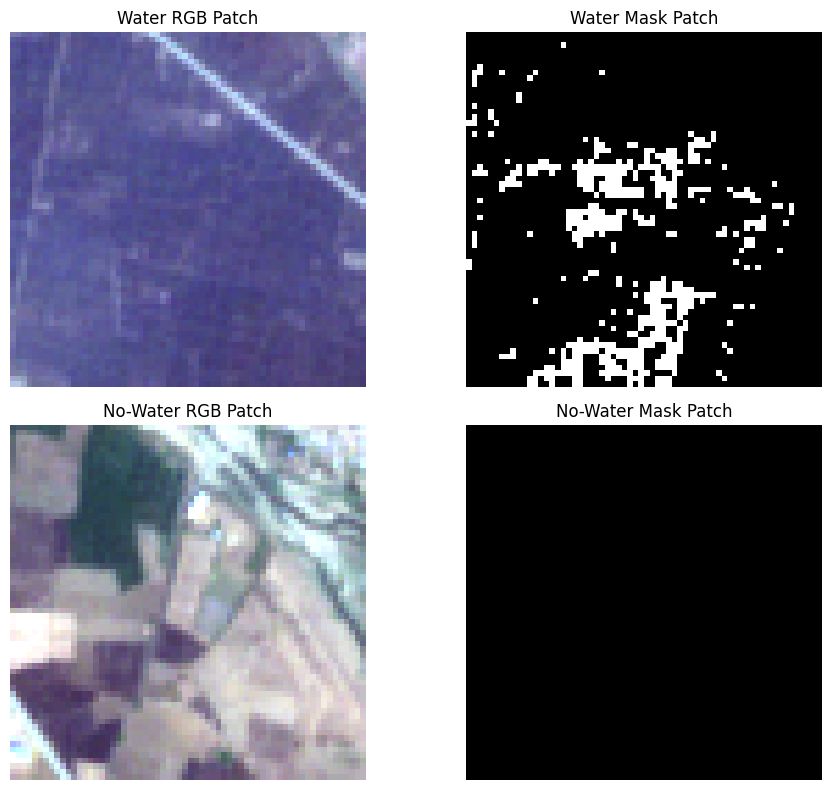

In [13]:
water_rgb_samples = sorted(glob.glob(os.path.join(water_rgb_dir, "*.png")))
water_mask_samples = sorted(glob.glob(os.path.join(water_mask_dir, "*.png")))

nowater_rgb_samples = sorted(glob.glob(os.path.join(nowater_rgb_dir, "*.png")))
nowater_mask_samples = sorted(glob.glob(os.path.join(nowater_mask_dir, "*.png")))

plt.figure(figsize=(10, 8))

if len(water_rgb_samples) > 0:
    plt.subplot(2, 2, 1)
    plt.imshow(Image.open(water_rgb_samples[0]))
    plt.title("Water RGB Patch")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(Image.open(water_mask_samples[0]), cmap="gray")
    plt.title("Water Mask Patch")
    plt.axis("off")

if len(nowater_rgb_samples) > 0:
    plt.subplot(2, 2, 3)
    plt.imshow(Image.open(nowater_rgb_samples[0]))
    plt.title("No-Water RGB Patch")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(Image.open(nowater_mask_samples[0]), cmap="gray")
    plt.title("No-Water Mask Patch")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 8
CNN_EPOCHS = 3
UNET_EPOCHS = 3
LEARNING_RATE = 0.001

print("Device:", DEVICE)

Device: cuda


In [15]:
class WaterClassificationDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB").resize((128, 128))
        image = np.array(image).astype(np.float32) / 255.0
        image = torch.tensor(image).permute(2, 0, 1)

        label = torch.tensor(label, dtype=torch.long)

        return image, label


water_files = sorted(glob.glob(os.path.join(water_rgb_dir, "*.png")))
nowater_files = sorted(glob.glob(os.path.join(nowater_rgb_dir, "*.png")))

all_data = [(p, 1) for p in water_files] + [(p, 0) for p in nowater_files]
random.shuffle(all_data)

print("Water samples:", len(water_files))
print("No-water samples:", len(nowater_files))
print("Total samples:", len(all_data))

train_data, temp_data = train_test_split(
    all_data,
    test_size=0.3,
    random_state=42,
    stratify=[label for _, label in all_data]
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42,
    stratify=[label for _, label in temp_data]
)

train_loader = DataLoader(WaterClassificationDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WaterClassificationDataset(val_data), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(WaterClassificationDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Water samples: 227
No-water samples: 3484
Total samples: 3711
Train: 2597
Validation: 557
Test: 557


In [16]:
class WaterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x


cnn_model = WaterCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)

print(cnn_model)

WaterCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)

In [17]:
cnn_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(CNN_EPOCHS):
    cnn_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = cnn_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    cnn_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = cnn_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    cnn_history["train_loss"].append(train_loss / len(train_loader))
    cnn_history["val_loss"].append(val_loss / len(val_loader))
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{CNN_EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

torch.save(cnn_model.state_dict(), os.path.join(OUTPUT_DIR, "cnn_model.pth"))

print("CNN model saved.")

Epoch 1/3 | Train Acc: 0.9661 | Val Acc: 0.9749
Epoch 2/3 | Train Acc: 0.9861 | Val Acc: 0.9946
Epoch 3/3 | Train Acc: 0.9873 | Val Acc: 0.9928
CNN model saved.


In [18]:
cnn_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = cnn_model(images)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["No Water", "Water"]
))

Confusion Matrix:
[[520   3]
 [  1  33]]

Classification Report:
              precision    recall  f1-score   support

    No Water       1.00      0.99      1.00       523
       Water       0.92      0.97      0.94        34

    accuracy                           0.99       557
   macro avg       0.96      0.98      0.97       557
weighted avg       0.99      0.99      0.99       557



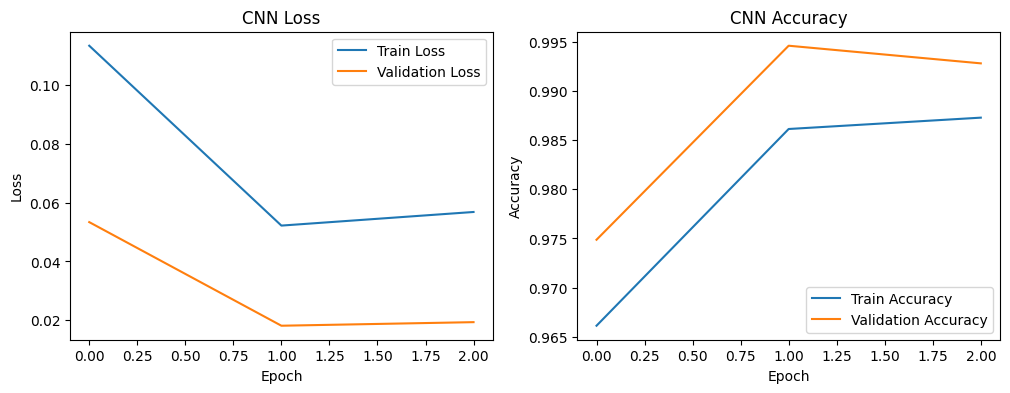

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(cnn_history["train_loss"], label="Train Loss")
plt.plot(cnn_history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history["train_acc"], label="Train Accuracy")
plt.plot(cnn_history["val_acc"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [20]:
class CNNGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(image_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(DEVICE)

        for i, weight in enumerate(weights):
            cam += weight * activations[i]

        cam = F.relu(cam)

        if cam.max() != 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam.detach().cpu().numpy(), class_idx

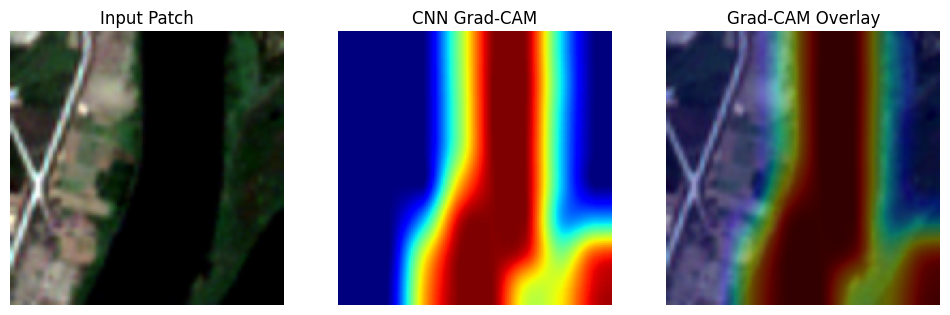

Actual class: Water
Predicted class: Water


In [21]:
gradcam = CNNGradCAM(cnn_model, cnn_model.conv4)

water_test_samples = [item for item in test_data if item[1] == 1]

if len(water_test_samples) > 0:
    sample_path, sample_label = water_test_samples[0]
else:
    sample_path, sample_label = test_data[0]

sample_img = Image.open(sample_path).convert("RGB").resize((128, 128))
sample_arr = np.array(sample_img).astype(np.float32) / 255.0

sample_tensor = torch.tensor(sample_arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

heatmap, predicted_class = gradcam.generate(sample_tensor)

heatmap_img = Image.fromarray(np.uint8(255 * heatmap)).resize((128, 128))
heatmap_arr = np.array(heatmap_img) / 255.0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_arr)
plt.title("Input Patch")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_arr, cmap="jet")
plt.title("CNN Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_arr)
plt.imshow(heatmap_arr, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

print("Actual class:", "Water" if sample_label == 1 else "No Water")
print("Predicted class:", "Water" if predicted_class == 1 else "No Water")

In [22]:
class WaterSegmentationDataset(Dataset):
    def __init__(self, rgb_paths, mask_paths):
        self.rgb_paths = list(rgb_paths)
        self.mask_paths = list(mask_paths)

    def __len__(self):
        return len(self.rgb_paths)

    def __getitem__(self, idx):
        image = Image.open(self.rgb_paths[idx]).convert("RGB").resize((128, 128))
        mask = Image.open(self.mask_paths[idx]).convert("L").resize((128, 128))

        image = np.array(image).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.float32) / 255.0

        mask = (mask > 0.5).astype(np.float32)

        image = torch.tensor(image).permute(2, 0, 1)
        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask


water_rgb = sorted(glob.glob(os.path.join(water_rgb_dir, "*.png")))
water_masks = sorted(glob.glob(os.path.join(water_mask_dir, "*.png")))

nowater_rgb = sorted(glob.glob(os.path.join(nowater_rgb_dir, "*.png")))
nowater_masks = sorted(glob.glob(os.path.join(nowater_mask_dir, "*.png")))

all_rgb = water_rgb + nowater_rgb
all_masks = water_masks + nowater_masks

combined = list(zip(all_rgb, all_masks))
random.shuffle(combined)

all_rgb, all_masks = zip(*combined)

train_rgb, temp_rgb, train_masks, temp_masks = train_test_split(
    all_rgb,
    all_masks,
    test_size=0.3,
    random_state=42
)

val_rgb, test_rgb, val_masks, test_masks = train_test_split(
    temp_rgb,
    temp_masks,
    test_size=0.5,
    random_state=42
)

train_seg_loader = DataLoader(
    WaterSegmentationDataset(train_rgb, train_masks),
    batch_size=8,
    shuffle=True
)

val_seg_loader = DataLoader(
    WaterSegmentationDataset(val_rgb, val_masks),
    batch_size=8,
    shuffle=False
)

test_seg_loader = DataLoader(
    WaterSegmentationDataset(test_rgb, test_masks),
    batch_size=8,
    shuffle=False
)

print("UNet train:", len(train_rgb))
print("UNet validation:", len(val_rgb))
print("UNet test:", len(test_rgb))

UNet train: 2597
UNet validation: 557
UNet test: 557


In [23]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = self.double_conv(3, 64)
        self.enc2 = self.double_conv(64, 128)
        self.enc3 = self.double_conv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = self.double_conv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = self.double_conv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.double_conv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self.double_conv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)


unet_model = UNet().to(DEVICE)
unet_criterion = nn.BCEWithLogitsLoss()
unet_optimizer = optim.Adam(unet_model.parameters(), lr=LEARNING_RATE)

print("UNet model ready.")

UNet model ready.


In [24]:
unet_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(UNET_EPOCHS):
    unet_model.train()
    train_loss = 0
    train_correct = 0
    train_pixels = 0

    for images, masks in train_seg_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        unet_optimizer.zero_grad()

        outputs = unet_model(images)
        loss = unet_criterion(outputs, masks)

        loss.backward()
        unet_optimizer.step()

        train_loss += loss.item()

        predictions = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (predictions == masks).sum().item()
        train_pixels += masks.numel()

    unet_model.eval()
    val_loss = 0
    val_correct = 0
    val_pixels = 0

    with torch.no_grad():
        for images, masks in val_seg_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = unet_model(images)
            loss = unet_criterion(outputs, masks)

            val_loss += loss.item()

            predictions = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (predictions == masks).sum().item()
            val_pixels += masks.numel()

    train_epoch_loss = train_loss / len(train_seg_loader)
    val_epoch_loss = val_loss / len(val_seg_loader)
    train_epoch_acc = train_correct / train_pixels
    val_epoch_acc = val_correct / val_pixels

    unet_history["train_loss"].append(train_epoch_loss)
    unet_history["val_loss"].append(val_epoch_loss)
    unet_history["train_acc"].append(train_epoch_acc)
    unet_history["val_acc"].append(val_epoch_acc)

    print(
        f"Epoch {epoch + 1}/{UNET_EPOCHS} | "
        f"Train Loss: {train_epoch_loss:.4f} | "
        f"Val Loss: {val_epoch_loss:.4f} | "
        f"Train Acc: {train_epoch_acc:.4f} | "
        f"Val Acc: {val_epoch_acc:.4f}"
    )

torch.save(unet_model.state_dict(), os.path.join(OUTPUT_DIR, "unet_model.pth"))
print("UNet model saved.")

Epoch 1/3 | Train Loss: 0.0410 | Val Loss: 0.0219 | Train Acc: 0.9871 | Val Acc: 0.9931
Epoch 2/3 | Train Loss: 0.0235 | Val Loss: 0.0327 | Train Acc: 0.9930 | Val Acc: 0.9922
Epoch 3/3 | Train Loss: 0.0210 | Val Loss: 0.0208 | Train Acc: 0.9937 | Val Acc: 0.9923
UNet model saved.


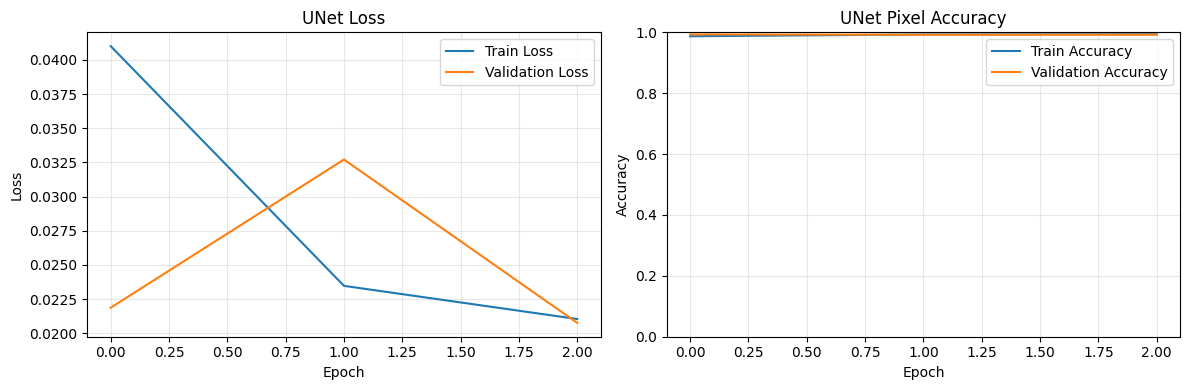

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(unet_history["train_loss"], label="Train Loss")
plt.plot(unet_history["val_loss"], label="Validation Loss")
plt.title("UNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(unet_history["train_acc"], label="Train Accuracy")
plt.plot(unet_history["val_acc"], label="Validation Accuracy")
plt.title("UNet Pixel Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Selected patch water coverage: 75.81%


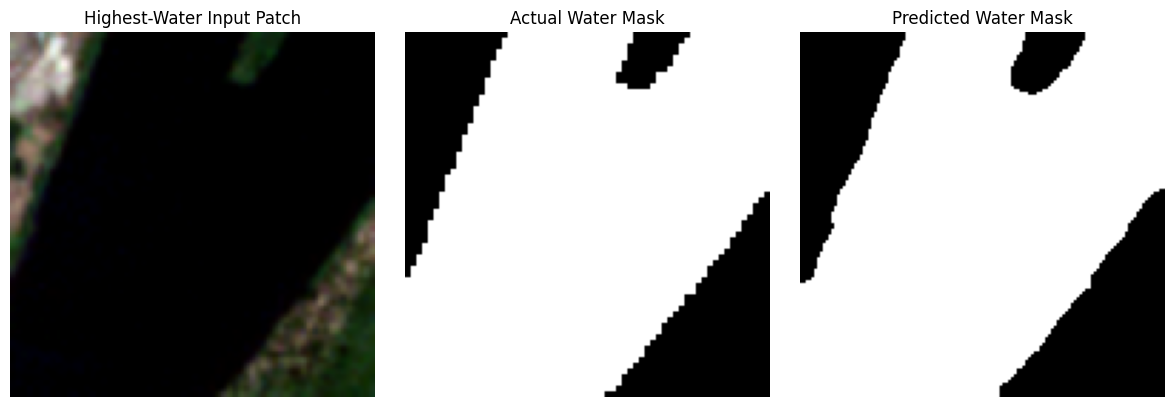

In [26]:
unet_model.eval()

best_water_ratio = -1
selected_image = None
selected_mask = None

for images, masks in test_seg_loader:
    water_ratios = masks.flatten(start_dim=1).mean(dim=1)

    best_idx_in_batch = torch.argmax(water_ratios).item()
    batch_best_ratio = water_ratios[best_idx_in_batch].item()

    if batch_best_ratio > best_water_ratio:
        best_water_ratio = batch_best_ratio
        selected_image = images[best_idx_in_batch].unsqueeze(0).to(DEVICE)
        selected_mask = masks[best_idx_in_batch]

if selected_image is None or best_water_ratio <= 0:
    raise ValueError("No water sample found in the test set.")

print(f"Selected patch water coverage: {best_water_ratio * 100:.2f}%")

with torch.no_grad():
    output = unet_model(selected_image)
    pred = (torch.sigmoid(output) > 0.5).float()

image_display = selected_image.cpu().squeeze(0)
mask_display = selected_mask.cpu().squeeze()
pred_display = pred.cpu().squeeze()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_display.permute(1, 2, 0))
plt.title("Highest-Water Input Patch")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_display, cmap="gray")
plt.title("Actual Water Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_display, cmap="gray")
plt.title("Predicted Water Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
pred_bool = pred.cpu().squeeze() > 0.5
mask_bool = selected_mask.cpu().squeeze() > 0.5

tp = (pred_bool & mask_bool).sum().item()
fp = (pred_bool & ~mask_bool).sum().item()
fn = (~pred_bool & mask_bool).sum().item()

dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
iou = tp / (tp + fp + fn + 1e-7)

print(f"Patch Dice score: {dice:.4f}")
print(f"Patch IoU score:  {iou:.4f}")

Patch Dice score: 0.9835
Patch IoU score:  0.9675


Selected patch water coverage: 75.81%
Grad-CAM target layer: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


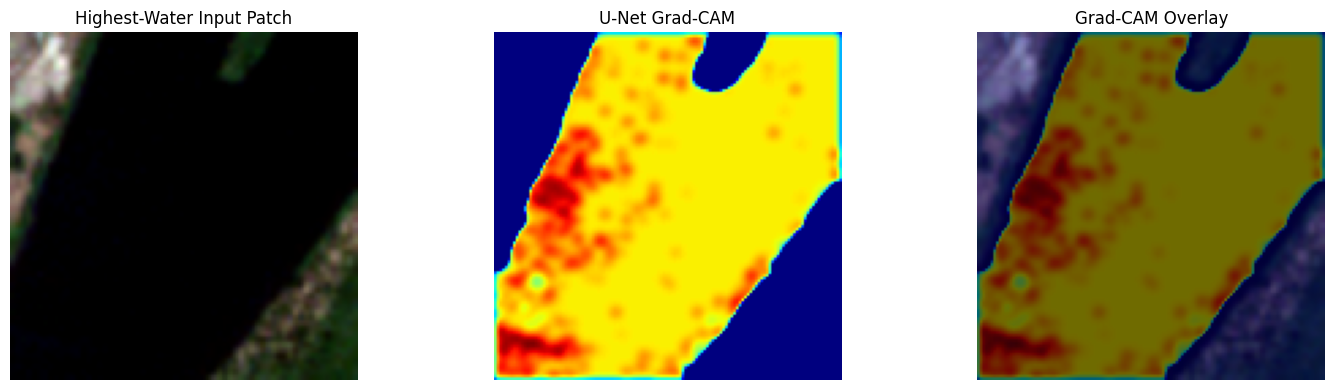

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

unet_model.eval()

best_water_ratio = -1
selected_image = None
selected_mask = None

for images, masks in test_seg_loader:
    water_ratios = masks.flatten(start_dim=1).mean(dim=1)

    best_idx = torch.argmax(water_ratios).item()
    batch_best_ratio = water_ratios[best_idx].item()

    if batch_best_ratio > best_water_ratio:
        best_water_ratio = batch_best_ratio
        selected_image = images[best_idx].unsqueeze(0).to(DEVICE)
        selected_mask = masks[best_idx]

if selected_image is None or best_water_ratio <= 0:
    raise ValueError("No water sample found in the test set.")

print(f"Selected patch water coverage: {best_water_ratio * 100:.2f}%")


class UNetGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        self.hook_handle = target_layer.register_forward_hook(
            self._save_activations
        )

    def _save_activations(self, module, inputs, output):
        self.activations = output
        output.register_hook(self._save_gradients)

    def _save_gradients(self, gradients):
        self.gradients = gradients

    def generate(self, image_tensor):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits = self.model(image_tensor)
        probabilities = torch.sigmoid(logits)

        height, width = probabilities.shape[-2:]
        best_pixel = torch.argmax(probabilities[0, 0]).item()

        y = best_pixel // width
        x = best_pixel % width

        score = logits[0, 0, y, x]
        score.backward()

        activations = self.activations[0]
        gradients = self.gradients[0]

        weights = gradients.mean(dim=(1, 2), keepdim=True)
        cam = F.relu((weights * activations).sum(dim=0))

        cam = F.interpolate(
            cam.unsqueeze(0).unsqueeze(0),
            size=image_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        ).squeeze()

        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam.detach().cpu().numpy(), probabilities.detach().cpu()


conv_layers = [
    layer for layer in unet_model.modules()
    if isinstance(layer, nn.Conv2d)
]

if len(conv_layers) < 2:
    raise ValueError("Could not locate a decoder convolution layer.")

target_layer = conv_layers[-2]

print("Grad-CAM target layer:", target_layer)

gradcam = UNetGradCAM(unet_model, target_layer)
heatmap, probability_map = gradcam.generate(selected_image)


image_display = selected_image.cpu().squeeze(0).permute(1, 2, 0).numpy()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_display)
plt.title("Highest-Water Input Patch")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("U-Net Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_display)
plt.imshow(heatmap, cmap="jet", alpha=0.45)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import shutil

drive_patch_dir = "/content/drive/MyDrive/CS2441/full_pipeline_output/patches"

if os.path.exists(drive_patch_dir):
    shutil.rmtree(drive_patch_dir)

shutil.copytree(PATCH_DIR, drive_patch_dir)

print("Full pipeline completed.")
print("Preprocessing completed")
print("Patch creation completed")
print("CNN classification completed")
print("CNN Grad-CAM completed")
print("UNet segmentation completed")
print("UNet predicted mask displayed")
print("Patches saved at:", drive_patch_dir)
print("Models saved at:", OUTPUT_DIR)

Full pipeline completed.
Preprocessing completed
Patch creation completed
CNN classification completed
CNN Grad-CAM completed
UNet segmentation completed
UNet predicted mask displayed
Patches saved at: /content/drive/MyDrive/CS2441/full_pipeline_output/patches
Models saved at: /content/drive/MyDrive/CS2441/full_pipeline_output
